# Classification 2

## Exercise 5: Classification using Logistic Regression

### Overview

In this exercise, we will begin our classification journey by building a baseline model using Logistic Regression.

### Library Imports

In [1]:
# Basic Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc

## Data Ingestion

In [2]:
# TASK: Read in the CSV file saved from Exercise 1
file_path = "Dataset/telco_churn.csv"
# The 1st column of the csv file should be the customer ID, which is loaded in the the Dataframe's index
input_data = pd.read_csv(file_path, index_col=0)

In [3]:
# Validate that data is as expected
input_data.head()

,Gender,SeniorCitizen,Partner,Dependents,TenureMonths,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ChurnLabel
CustomerID,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,M2M,Yes,mcheck,53.85,108.15,Yes
9237-HQITU,Female,No,No,Yes,2,Yes,No,FiberOptic,No,No,No,No,No,No,M2M,Yes,echeck,70.70,151.65,Yes
9305-CDSKC,Female,No,No,Yes,8,Yes,Yes,FiberOptic,No,No,Yes,No,Yes,Yes,M2M,Yes,echeck,99.65,820.50,Yes
7892-POOKP,Female,No,Yes,Yes,28,Yes,Yes,FiberOptic,No,No,Yes,Yes,Yes,Yes,M2M,Yes,echeck,104.80,3046.05,Yes
0280-XJGEX,Male,No,No,Yes,49,Yes,Yes,FiberOptic,No,Yes,Yes,No,Yes,Yes,M2M,Yes,transfer,103.70,5036.30,Yes


In [4]:
# Size of data - TASK: Validate that it's (7032, 20)
input_data.shape

(7032, 20)

## Feature Engineering

In [5]:
# Outcome variable
# Instead of keeping the values, we will encode as 1s and 0s using the map function
output_var_name = 'ChurnLabel'
output_var = input_data[output_var_name]
output_var = output_var.map({'Yes': 1, 'No': 0})
# Note that the map function can be run only once. You will get an error if you try to run this cell again as Yes/No are no longer valid values in this feature. 

# Count the number of rows for each outcome value
print("Row count for each outcome")
print(output_var.value_counts())

# Remove the outcome variable from the main dataframe
input_data.drop(output_var_name, axis=1, inplace=True)

Row count for each outcome
ChurnLabel
0    5163
1    1869
Name: count, dtype: int64


In [6]:
# Next, we want to define 3 lists for each of the data types found in our data i.e. Numerical, Categorical (more than 2 values), Binary (2 values only)

# Numerical features
num_features = [key for key in dict(input_data.dtypes) if dict(input_data.dtypes)[key] in ['int64', 'float64']]
print(num_features) # TASK: Confirm the columns based on Exercise 1

['TenureMonths', 'MonthlyCharges', 'TotalCharges']


In [7]:
# TASK: Define the 4 categorical features as a list of strings. These are the non-numerical features that do not have Yes/No values

# Exclude identifier and target columns
ignore_cols = ['CustomerID', 'ChurnLabel']

# TASK: Extract non-binary categorical features
cat_features = [
    col for col in input_data.select_dtypes(include=['object']).columns 
    if col not in ignore_cols and not set(input_data[col].dropna().unique()).issubset({'Yes', 'No'})
]

print(cat_features)

['Gender', 'InternetService', 'Contract', 'PaymentMethod']


/tmp/ipykernel_1765/4002414551.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in input_data.select_dtypes(include=['object']).columns


In [8]:
# TASK: Define the binary features. Complete the steps denoted in this cell.
# 1. Get the list of non-numerical features (both categorical and binary). Hint: Add 'not' to the code from num_features
bin_features = [key for key in dict(input_data.dtypes) if dict(input_data.dtypes)[key] not in ['int64', 'float64']] # Copy then modify the code from num_features

# 2. Remove the categorical feature names from this list
for col in cat_features:
    bin_features.remove(col)
    # Hint: There is a list method to remove an element
print(f"List of binary features: {bin_features}") # TASK: Confirm the resulting list

List of binary features: ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']


In [9]:
# Encoding the binary features. Similar to the outcome variable, we will need to convert the values of these features from Yes/No to 1/0.
# Note: As an alternative, this could have been done when building the pipeline.
# TASK: Complete the code 
for col in bin_features:
    input_data[col] = input_data[col].map({'Yes': 1, 'No': 0})

In [10]:
# Display values after encoding
input_data.head()

,Gender,SeniorCitizen,Partner,Dependents,TenureMonths,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
CustomerID,,,,,,,,,,,,,,,,,,,
3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,M2M,1,mcheck,53.85,108.15
9237-HQITU,Female,0,0,1,2,1,0,FiberOptic,0,0,0,0,0,0,M2M,1,echeck,70.70,151.65
9305-CDSKC,Female,0,0,1,8,1,1,FiberOptic,0,0,1,0,1,1,M2M,1,echeck,99.65,820.50
7892-POOKP,Female,0,1,1,28,1,1,FiberOptic,0,0,1,1,1,1,M2M,1,echeck,104.80,3046.05
0280-XJGEX,Male,0,0,1,49,1,1,FiberOptic,0,1,1,0,1,1,M2M,1,transfer,103.70,5036.30


## Model Building

In [11]:
# Define preprocessing pipeline. Reminder that the binary features have already been encoded and thus only passed through
# TASK: Match the list of features to the correct encoding operation. 
# Remember to add the library imports for ColumnTransformer, StandardScaler, OneHotEncoder to the imports above
preprocess = ColumnTransformer(
    transformers=[
        ('standardscaler', StandardScaler(), num_features),
        ('onehotencoder', OneHotEncoder(), cat_features)
    ],
    remainder='passthrough'
)

In [14]:
# TASK: Complete the pipeline by adding the KNN Algorithm i.e. KNeighborClassifier
# At this moment, use the n_neighbors=5 as the parameter to KNeighborClassifier. Once this script is working, feel free to try out other values.
model_knn = make_pipeline(
    preprocess,
    KNeighborsClassifier(n_neighbors=5) # TASK
)

model_dt = make_pipeline(
     preprocess,
     DecisionTreeClassifier(random_state=42,
                           max_depth=3,
                           max_features=0.4,
                           min_samples_leaf=0.08)
)

model_lr = make_pipeline(
     preprocess,
     LogisticRegression()
)

clfs = [
    ('KNN', model_knn),
    ('Decision Tree', model_dt),
    ('Logistic Regression', model_lr)
]

In [15]:
# Train/Test Split
# TASK: Split the data into 70:30 train/test. Use the random_state=42
X = input_data
y = output_var

x_train, x_test, y_train, y_test = train_test_split(input_data, output_var, test_size=0.3, random_state=42)  # TASK

In [16]:
# Check the dimensions of the data. TASK: Confirm as (2110, 19)
x_test.shape

(2110, 19)

In [17]:
# Train the pipeline. You can add a semi-colon (';') at the end of the line to supresses the output printing
for clf_name, clf in clfs:
    clf.fit(x_train, y_train)
    pred_test = clf.predict(x_test)

    # Calculate the metrics used to evaluate previous models
    f1 = f1_score(y_test, pred_test)
    print('{:s} : {:.3f}'.format(clf_name, f1)) 

KNN : 0.604
Decision Tree : 0.613
Logistic Regression : 0.649


In [18]:
model = VotingClassifier(estimators=clfs)
model.fit(x_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('KNN', ...), ('Decision Tree', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[Pipeline(step...lassifier())]), Pipeline(step...m_state=42))]), Pipeline(step...egression())])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


### Evaluation

For regression problems, we are familiar with common metrics such as Root Means Square Error (RMSE) and the Coefficient of Determination (R<sup>2</sup> value).

With classification problems, we need a different set of metrics to evaluate the model. Here, we use metrics such as:

- Confusion Matrix
- Precision
- Recall
- F1 score
- ROC and AUC

Read the following blog posts to get familiar with these terms:

- https://hackernoon.com/idiots-guide-to-precision-recall-and-confusion-matrix-b32d36463556
- https://towardsdatascience.com/accuracy-precision-recall-or-f1-331fb37c5cb9

Once you are done, proceed to the next cells.


In [19]:
# Apply the model on the test data
pred_test = model.predict(x_test)

In [30]:
# TASK: Import the following metrics from scikit-learn in the library imports section above
# confusion_matrix, accuracy_score, precision, recall, f1_score, classification_report, roc_curve, auc
# Note that all these functions have the same parameter profile i.e. the first parameter contains the actual values while the second parameter contains the predicted values from the model.

In [20]:
# TASK: Calculate the confusion matrix
cm = confusion_matrix(y_test, pred_test)  # TASK
print(cm)

[[1349  173]
 [ 224  364]]


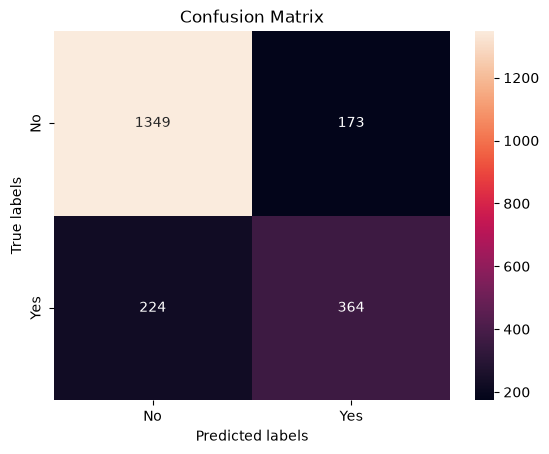

In [21]:
# Confusion Matrices typically are displayed in a graphical manner. Run this cell to display the matrix using this code snippet found online.
labels = ['No','Yes']
ax= plt.subplot()
sn.heatmap(cm, annot=True, ax = ax, fmt="d"); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(labels); ax.yaxis.set_ticklabels(labels)
plt.show()

In [22]:
# TASK: Calculate the 4 following metrics using the correct function
# OPTIONAL: Calculate these metrics by hand (using the formulas in the reference blog posts) to validate the values

# 1. Accuracy = Sum of correctly predicted outcomes divided by total number of samples
accuracy = accuracy_score(y_test, pred_test) # TASK
print("Accuracy: {:.5f}".format(accuracy))

Accuracy: 0.81185


In [23]:
# 2. Precision - Of those predicted positive, how many of them are actual positive.
precision = precision_score(y_test, pred_test) # TASK
print("Precision: {:.5f}".format(precision))

Precision: 0.67784


In [24]:
# 3. Recall - how many of the actual positives our model is predicting as positives
recall = recall_score(y_test, pred_test) # TASK
print("Recall: {:.5f}".format(recall))

Recall: 0.61905


In [25]:
# 4. F1 score
f1 = f1_score(y_test, pred_test) #TASK
print("F1 Score: {:.5f}".format(f1))

F1 Score: 0.64711


In [26]:
# Alternatively, we can calculate all these metrics in one call using the classification_report function
print(classification_report(y_test, pred_test, digits=5))

              precision    recall  f1-score   support

           0    0.85760   0.88633   0.87173      1522
           1    0.67784   0.61905   0.64711       588

    accuracy                        0.81185      2110
   macro avg    0.76772   0.75269   0.75942      2110
weighted avg    0.80750   0.81185   0.80913      2110



At this point, take a step back and try to understand these numbers. 

- What do these metrics mean in the context of the problem? 
- Which error (Type 1 or Type 2) is more important for this problem? And thus which metric is more important, Precision or Recall?

In [27]:
# TASK: Compute ROC and AUC. Note that roc_curve() returns 3 values. You will only need the first 2 as input to auc() i.e. use _ as the 3rd output
fpr, tpr, _ = roc_curve(y_test, pred_test)  # TASK
roc_auc = auc(fpr, tpr)

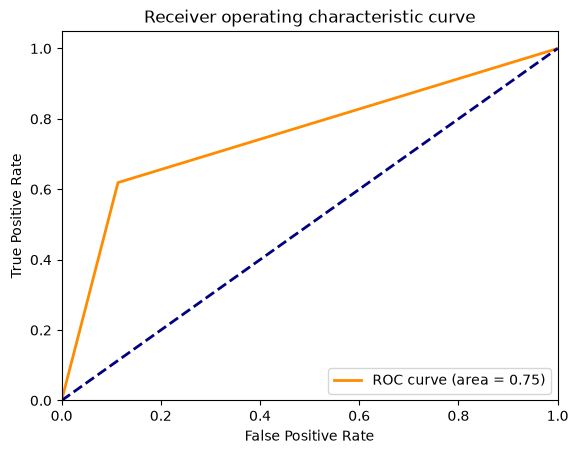

In [28]:
# Run this cell to plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange',
         lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic curve')
plt.legend(loc="lower right")
plt.show()

Congratulations! You have built a basic classication model. Complete the lesson quiz and proceed to the next lesson.